In [2]:
import pandas as pd
import numpy as np

# 1. Define the 26 column names based on the NASA manual
columns = ['engine_id', 'cycle', 'op_setting_1', 'op_setting_2', 'op_setting_3'] + \
          [f'sensor_{i}' for i in range(1, 22)] # This automatically names sensors 1 to 21

# 2. Load the Training Data (The textbook for the AI)
train_df = pd.read_csv('../data/raw/train_FD001.txt', sep='\s+', header=None, names=columns)

# 3. Load the Testing Data (The final exam)
test_df = pd.read_csv('../data/raw/test_FD001.txt', sep='\s+', header=None, names=columns)

# 4. Load the True RUL Data (The teacher's answer key for the test)
true_rul = pd.read_csv('../data/raw/RUL_FD001.txt', sep='\s+', header=None, names=['true_rul'])
true_rul['engine_id'] = true_rul.index + 1 # Assign engine IDs 1 to 100

print("Data successfully loaded! 🚀")


Data successfully loaded! 🚀


In [3]:
# 1. Find the final flight cycle for each engine in the training data
max_cycles = train_df.groupby('engine_id')['cycle'].max().reset_index()
max_cycles.columns = ['engine_id', 'max_cycle']

# 2. Merge this maximum cycle back into our main table
train_df = train_df.merge(max_cycles, on='engine_id', how='left')

# 3. Calculate exact RUL: (Max Cycle - Current Cycle)
train_df['RUL'] = train_df['max_cycle'] - train_df['cycle']

# 4. The Genius Step: Piecewise RUL
# Engines don't degrade from day 1. We cap the RUL at 125 flights. 
# This tells the AI: "If RUL is above 125, the engine is perfectly healthy, don't worry about it."
train_df['RUL'] = train_df['RUL'].clip(upper=125)

# Drop the max_cycle column as we no longer need it
train_df.drop('max_cycle', axis=1, inplace=True)

print("Target Variable (RUL) successfully calculated! 🎯")
train_df[['engine_id', 'cycle', 'RUL']].head() # Shows you the first 5 rows


Target Variable (RUL) successfully calculated! 🎯


,engine_id,cycle,RUL
0,1,1,125
1,1,2,125
2,1,3,125
3,1,4,125
4,1,5,125


In [4]:
# 1. Identify useless sensors that never change their values
# Through data exploration, data scientists found these columns are constant
useless_columns = ['op_setting_3', 'sensor_1', 'sensor_5', 'sensor_10', 'sensor_16', 'sensor_18', 'sensor_19']

# 2. Drop them from both the Training and Testing data
train_df.drop(columns=useless_columns, inplace=True)
test_df.drop(columns=useless_columns, inplace=True)

# 3. Separate our "Features" (X) from our "Target" (y)
# X is the data the AI uses to guess. y is the answer we want it to predict.
X_train = train_df.drop(columns=['engine_id', 'cycle', 'RUL'])
y_train = train_df['RUL']

print("Data cleaned and ready for the AI! ✨")


Data cleaned and ready for the AI! ✨


In [5]:
# Import the Machine Learning tools from the scikit-learn library
from sklearn.ensemble import RandomForestRegressor

# 1. Initialize the AI Model (Give it 100 'trees' to think with)
model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)

print("Training the AI... please wait a few seconds ⏳")

# 2. Train the AI (This is where it studies the textbook)
model.fit(X_train, y_train)

print("AI Training Complete! 🎓")


Training the AI... please wait a few seconds ⏳
AI Training Complete! 🎓


In [6]:
from sklearn.metrics import mean_squared_error

# 1. We only want to predict the RUL for the VERY LAST recorded flight of each test engine
last_test_cycle = test_df.groupby('engine_id').last().reset_index()

# 2. Prepare the test features (drop engine ID and cycle, just like we did for training)
X_test = last_test_cycle.drop(columns=['engine_id', 'cycle'])

# 3. Ask the AI to make its predictions!
predictions = model.predict(X_test)

# 4. Compare the predictions to the true answers (Calculate the Error)
rmse = np.sqrt(mean_squared_error(true_rul['true_rul'], predictions))

print(f"Test Complete! The AI's margin of error (RMSE) is: {rmse:.2f} flights.")
print("An error around 15-20 is considered excellent for this dataset! 🏆")


Test Complete! The AI's margin of error (RMSE) is: 18.12 flights.
An error around 15-20 is considered excellent for this dataset! 🏆


In [7]:
import joblib
import os

# Create a 'models' folder if it doesn't exist
os.makedirs('../models', exist_ok=True)

# Save the model
joblib.dump(model, '../models/random_forest_engine_model.pkl')
print("Model saved successfully! 💾")


Model saved successfully! 💾


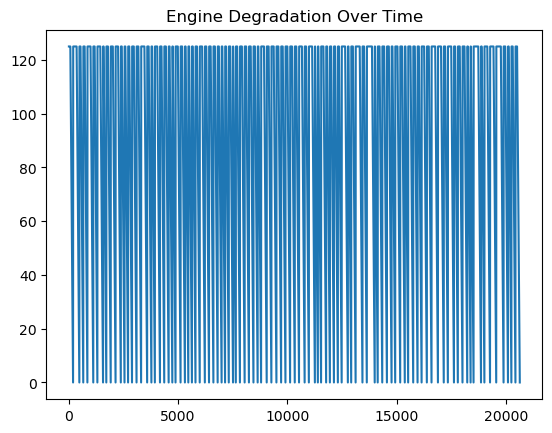

In [9]:
import matplotlib.pyplot as plt

# This tells Python: "Draw a line graph of the engine's Remaining Useful Life"
plt.plot(train_df['RUL'])

# This adds a title to the top of the picture
plt.title("Engine Degradation Over Time")

# This is the magic command that actually makes the picture pop up on your screen!
plt.show() 
